Mahan Madani - 830504035

## Table of Contents

- [Import Libraries and Configs](#import-libraries-and-configs)
- [Datasets and Dataloader](#datasets-and-dataloaders)
- [Find and Index CLIP Embeddings Using FAISS](#find-and-index-clip-embeddings-using-faiss)
- [Create Metadata Files to Store Image Captions](#create-metadata-files-to-store-image-captions)
- [Similar Image Retrieval Sample](#similar-image-retrieval-sample)
- [Load FAISS index and JSON Metadata (for future runs)](#load-faiss-index-and-json-metadata-for-future-runs)

## Import libraries and Configs

In [1]:
import os
import json
import faiss
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image
from torch.utils.data import DataLoader
from transformers import CLIPProcessor

In [ ]:
from Modules.config import (TRAIN_IMAGE_DIR,
                            TRAIN_CAPTIONS_PATH,
                            TEST_IMAGE_DIR,
                            TEST_CAPTIONS_PATH,
                            FAISS_PATH,
                            TRAIN_METADATA_PATH,
                            TEST_METADATA_PATH,
                            CLIP_MODEL_NAME)

from Modules.retrieval_module import Retriever
from Modules.datasets import Flickr30KImageDataset, CLIPDataCollator
from Modules.embedding_module import Embedder

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Datasets and Dataloaders

Place the flickr30k dataset in the dataset folder and run the data_preprocess notebook to split it into train-test subsets.

In [4]:
train_dataset = Flickr30KImageDataset(TRAIN_IMAGE_DIR, TRAIN_CAPTIONS_PATH)
test_dataset  = Flickr30KImageDataset(TEST_IMAGE_DIR,  TEST_CAPTIONS_PATH)

In [5]:
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME, use_fast=True)
collator = CLIPDataCollator(processor, DEVICE)

In [6]:
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collator)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collator)

## Find and Index CLIP Embeddings Using FAISS

In [7]:
embedder = Embedder(model_name=CLIP_MODEL_NAME, device=DEVICE)
faiss_index = faiss.IndexFlatIP(embedder.embedding_dim)  # use cosine similarity

In [ ]:
loader = tqdm(train_loader, desc="Extracting CLIP embeddings")

for batch in loader:
    images = batch['pixel_values'].to(DEVICE) # shape [B, 3, W, H] 
    embeddings = embedder.get_image_embedding(images)
    faiss_index.add(embeddings)

Extracting CLIP embeddings: 100%|██████████| 481/481 [03:44<00:00,  2.14it/s]


In [26]:
faiss.write_index(faiss_index, FAISS_PATH)
print(f"Indexed {faiss_index.ntotal} images")

Indexed 30783 images


## Create Metadata Files to Store Image Captions

In [9]:
retriever = Retriever(faiss_index=faiss_index)

train_metadata = {}
test_metadata = {}
train_index = 0
test_index = 0

Retriever created without metadata file.


In [ ]:
loader = tqdm(train_loader, desc="Finding similar images")

for batch in loader:
    images = batch['pixel_values'].to(DEVICE) # shape [B, 3, W, H]
    image_names = batch['image_names']
    captions = batch['captions']
    
    embeddings = embedder.get_image_embedding(images)

    for i in range(len(images)):
        similar_images = retriever.retrieve_similar_indices(embeddings[i].unsqueeze(0), k=6)
        train_metadata[train_index] = {
            "image_name": image_names[i],
            "captions": captions[i],
            "similar_images": similar_images[i][1:]
        }
        train_index += 1

Finding similar images: 100%|██████████| 962/962 [05:08<00:00,  3.12it/s]


In [ ]:
loader = tqdm(test_loader, desc="Finding similar images")

for batch in loader:
    images = batch['pixel_values'].to(DEVICE) # shape [B, 3, W, H]
    image_names = batch['image_names']
    captions = batch['captions']
    
    embeddings = embedder.get_image_embedding(images)

    for i in range(len(images)):
        similar_images = retriever.retrieve_similar_indices(embeddings[i].unsqueeze(0), k=5)
        test_metadata[test_index] = {
            "image_name": image_names[i],
            "captions": captions[i],
            "similar_images": similar_images[i]
        }
        test_index += 1

Finding similar images: 100%|██████████| 32/32 [00:09<00:00,  3.21it/s]


Save JSON Metadata

In [43]:
with open(TRAIN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(train_metadata, f, indent=2, ensure_ascii=False)
    
with open(TEST_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(test_metadata, f, indent=2, ensure_ascii=False)

## Similar Image Retrieval Sample

In [ ]:
# Function to display query image and the k most similar images
def display_images(query_image, retrieved_images):    
    n = len(retrieved_images) + 1
    plt.figure(figsize=(15, 4))

    plt.subplot(1, n, 1)
    plt.imshow(query_image)
    plt.axis('off') 
    plt.title("Test Image")

    for i in range(n-1):
        plt.subplot(1, n, i+2)
        image = retrieved_images[i]
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Retrieved Image {i+1}")

    plt.tight_layout()
    plt.show()

In [21]:
retriever.set_metadata(TRAIN_METADATA_PATH)

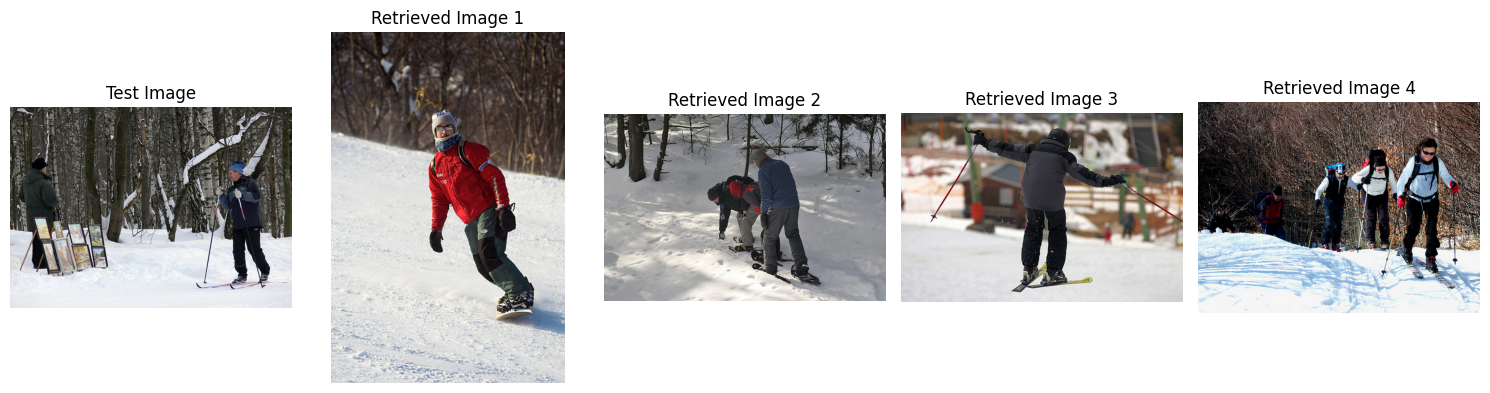

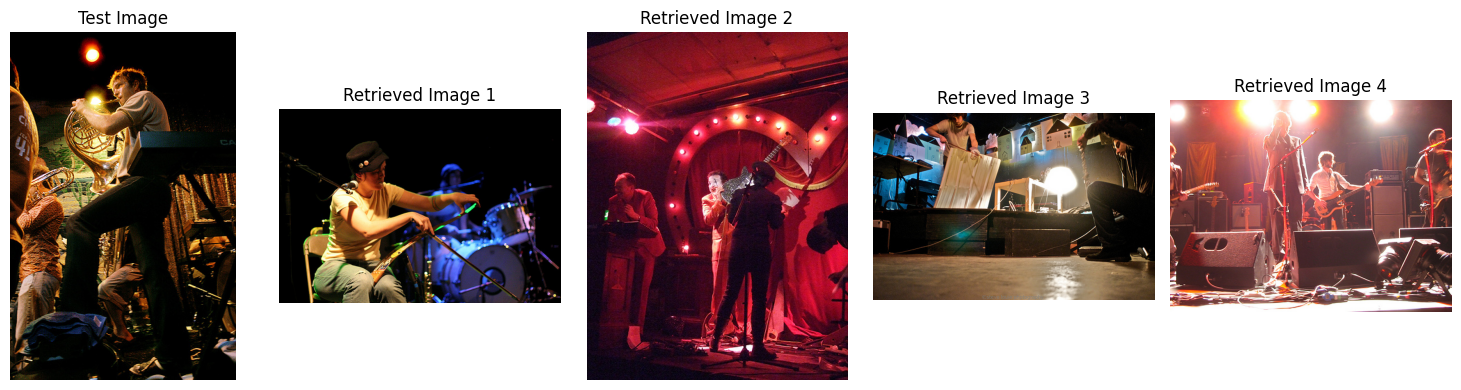

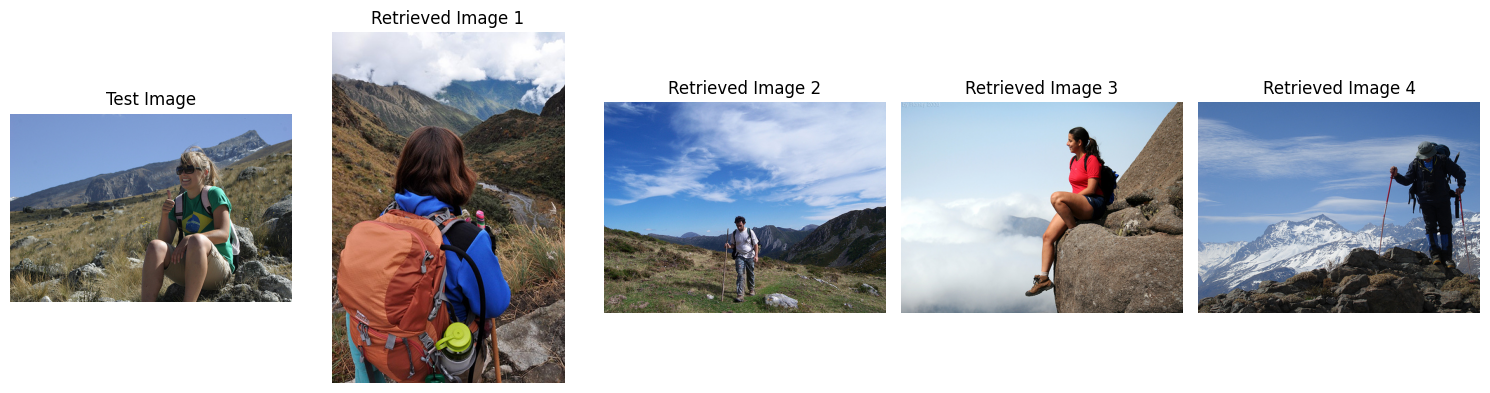

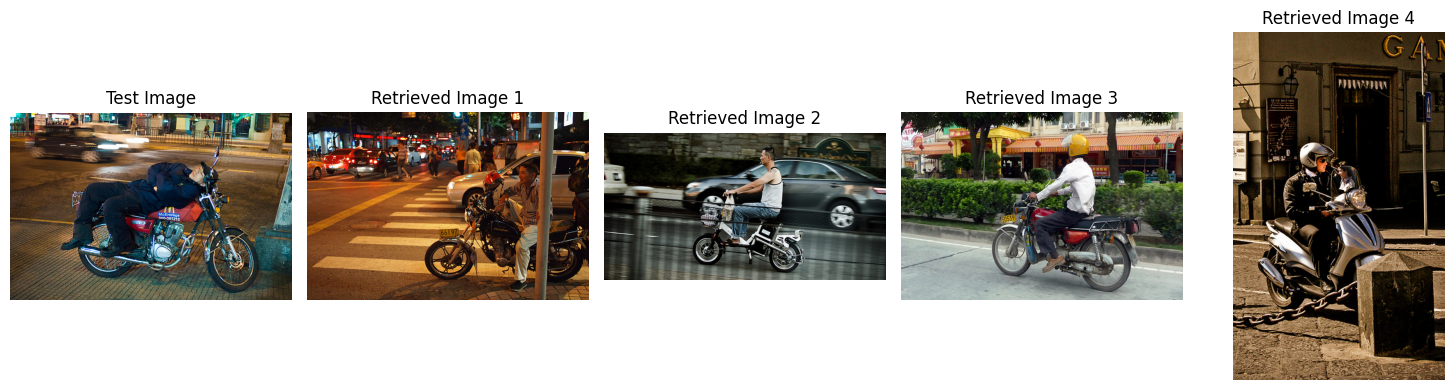

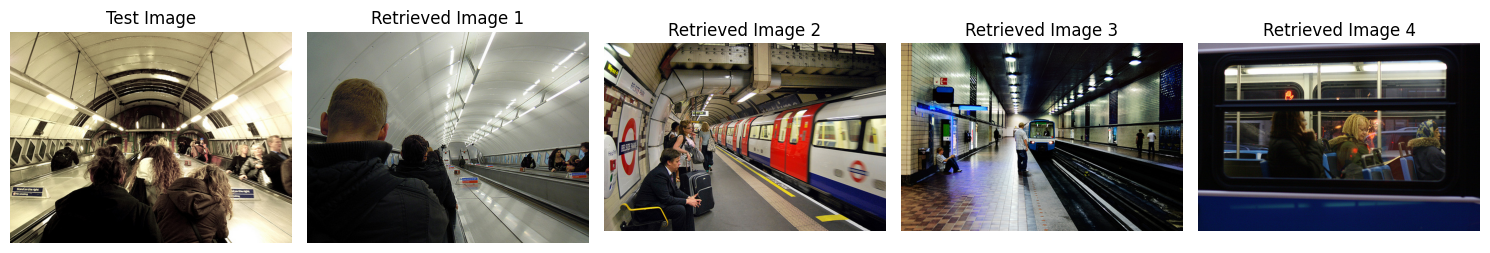

In [ ]:
sample_idx = [1, 112, 501, 777, 910]
k = 4

pixel_values = collator([test_dataset[idx] for idx in sample_idx])['pixel_values']
embeddings = embedder.get_image_embedding(pixel_values)
similar_images_idx = retriever.retrieve_similar_indices(embeddings, k=k)

for i in range(len(sample_idx)):
    query_image = test_dataset[sample_idx[i]]['image']
    similar_images = []
    for idx in similar_images_idx[i]:
        similar_images.append(train_dataset[idx]['image'])

    display_images(query_image, similar_images)

Sample Captions

In [60]:
query_image_metadata = test_metadata[str(sample_idx[-1])]
print("Query image captions:")
print(*query_image_metadata['captions'], sep='\n')

print("\nRetrieved Image Captions:")
for idx in query_image_metadata['similar_images'][:k]:
    similar_image_metadata = train_metadata[str(idx)]
    print(similar_image_metadata['image_name'])
    print(*similar_image_metadata['captions'], sep='\n', end='\n\n')

Query image captions:
A group of people is traveling through a terminal with moving walkways .
Crowds of people are riding escalators up and down in a large tunnel .
People at a terminal are on an elevator packed with others .
A group of people stand on a moving sidewalk .
A group of people going up an escalator .

Retrieved Image Captions:
5922190538.jpg
Several people going down an escalator  with a few others going up the up escalator .
People are riding an escalator up and down a subway station tunnel .
All the shoppers are moving up and down the escalator .
People standing in line in a crowded area .
People are lined up in a terminal

4762011238.jpg
People waiting for a subway train : one man in a black suit sitting on bench and three women standing or walking .
A man in a suit and tie and a woman with luggage join others in waiting in the London Underground .
People wait on a mass transit platform while a train speeds by .
A man in a black suite sitting in a train tunnel .
Pictur

## Load FAISS index and JSON Metadata (for future runs)

In [37]:
# faiss_index = faiss.read_index(FAISS_PATH)
faiss_index = faiss.read_index('flickr30k_clip_images.faiss')
print(f"Number of vectors in index: {faiss_index.ntotal}")

Number of vectors in index: 30783


In [56]:
with open(TRAIN_METADATA_PATH, "r", encoding="utf-8") as f:
    train_metadata = json.load(f)
    
with open(TEST_METADATA_PATH, "r", encoding="utf-8") as f:
    test_metadata = json.load(f)

print(train_metadata["0"])  # keys: 'title', 'captions', etc.

{'image_name': '1000092795.jpg', 'captions': ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'Two young  White males are outside near many bushes .', 'Two men in green shirts are standing in a yard .', 'A man in a blue shirt standing in a garden .', 'Two friends enjoy time spent together .'], 'similar_images': [10968, 1672, 15204, 22492, 24582]}
